In [1]:
import pandas as pd

trades = pd.read_csv(r"C:\Users\sidha\OneDrive\Desktop\resume\AI Project\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\sidha\OneDrive\Desktop\resume\AI Project\fear_greed_index.csv")

In [2]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [3]:
trades.isnull().sum()
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [4]:
df = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [5]:
df.groupby('classification')['Closed PnL'].agg(
    ['count','mean','sum']
)

,count,mean,sum
classification,,,
Extreme Fear,879,282.531145,2.483449e+05
Extreme Greed,2926,61.798681,1.808229e+05
Fear,8996,173.180636,1.557933e+06
Greed,6812,118.997495,8.106109e+05
Neutral,4920,126.446833,6.221184e+05


In [6]:
df['win'] = df['Closed PnL'] > 0

df.groupby('classification')['win'].mean()*100

classification
Extreme Fear     28.555176
Extreme Greed    20.539986
Fear             40.384615
Greed            36.597181
Neutral          47.174797
Name: win, dtype: float64

In [7]:
df.groupby('classification')['Size USD'].mean()

classification
Extreme Fear      7397.982924
Extreme Greed    11391.683688
Fear             29091.355252
Greed            22721.204169
Neutral          18071.809518
Name: Size USD, dtype: float64

In [9]:
top_traders = (
    df.groupby('Account')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

In [10]:
top_traders

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    6.873714e+04
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    6.784562e+04
0x8381e6d82f1affd39a336e143e081ef7620a3b7f    6.551366e+04
Name: Closed PnL, dtype: float64

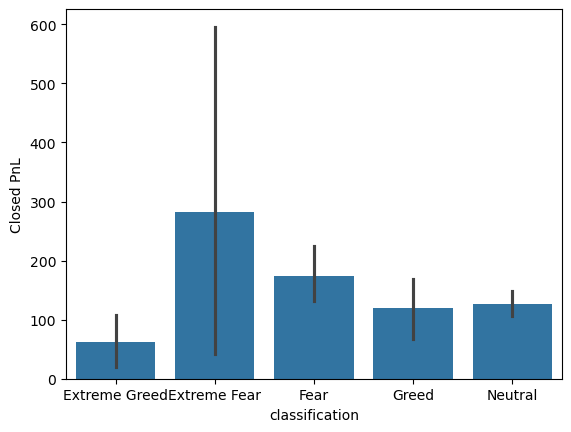

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x='classification',
    y='Closed PnL'
)
plt.show()

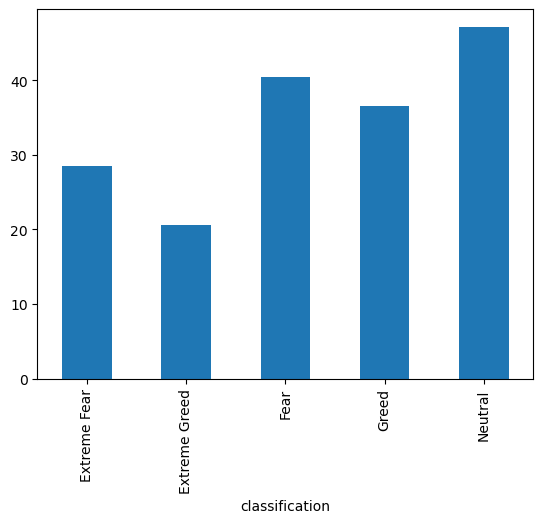

In [12]:
win_rate = (
    df.groupby('classification')['win']
      .mean()*100
)

win_rate.plot(kind='bar')
plt.show()

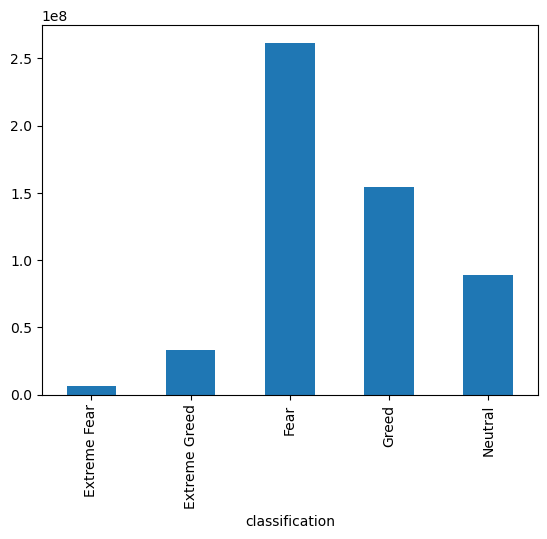

In [13]:
df.groupby('classification')['Size USD'].sum().plot(kind='bar')
plt.show()

In [15]:
avg_profit = df.groupby('classification')['Closed PnL'].mean()

best_sentiment = avg_profit.idxmax()
best_profit = avg_profit.max()

print(f"Traders achieved the highest average profit during {best_sentiment} periods with an average PnL of {best_profit:.2f}.")

Traders achieved the highest average profit during Extreme Fear periods with an average PnL of 282.53.


In [16]:
df['win'] = df['Closed PnL'] > 0

summary = df.groupby('classification').agg({
    'win':'mean',
    'Size USD':'mean'
})

summary['win'] = summary['win'] * 100

print(summary.sort_values('Size USD', ascending=False))

                      win      Size USD
classification                         
Fear            40.384615  29091.355252
Greed           36.597181  22721.204169
Neutral         47.174797  18071.809518
Extreme Greed   20.539986  11391.683688
Extreme Fear    28.555176   7397.982924


In [17]:
largest_size_sentiment = summary['Size USD'].idxmax()
lowest_win_rate = summary['win'].idxmin()

print(f"Largest average trade size occurred during {largest_size_sentiment}.")
print(f"Lowest win rate occurred during {lowest_win_rate}.")

Largest average trade size occurred during Fear.
Lowest win rate occurred during Extreme Greed.


In [19]:
mapping = {
    'Extreme Fear': 1,
    'Fear': 2,
    'Neutral': 3,
    'Greed': 4,
    'Extreme Greed': 5
}

df['sentiment_score'] = df['classification'].map(mapping)

correlation = df['sentiment_score'].corr(df['Closed PnL'])

print("Correlation:", correlation)

Correlation: -0.020794794001119957


In [20]:
if abs(correlation) > 0.1:
    print("Market sentiment significantly influences trader profitability.")
else:
    print("Market sentiment has weak influence on trader profitability.")

Market sentiment has weak influence on trader profitability.


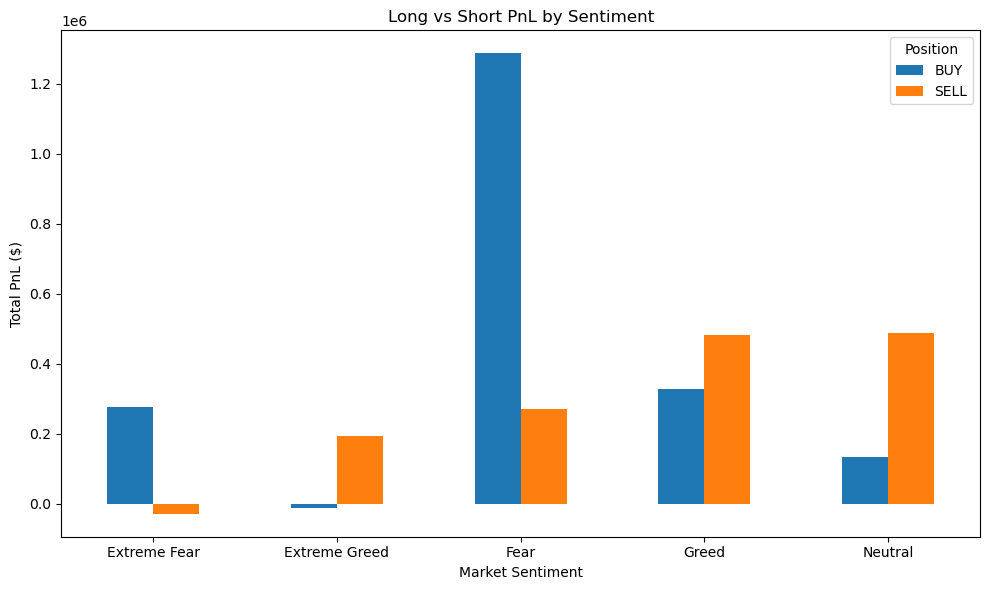

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

long_short = (
    df.groupby(['classification', 'Side'])['Closed PnL']
      .sum()
      .unstack(fill_value=0)
)

long_short.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Long vs Short PnL by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Total PnL ($)')
plt.xticks(rotation=0)
plt.legend(title='Position')
plt.tight_layout()
plt.show()

In [26]:
print(monthly_pnl.columns)
print(fg_monthly.columns)

Index(['month', 'Closed PnL'], dtype='object')
Index(['date', 'value'], dtype='object')


In [27]:
df['date'] = pd.to_datetime(df['date'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

df['month'] = df['date'].dt.to_period('M')
sentiment['month'] = sentiment['date'].dt.to_period('M')

monthly_pnl = (
    df.groupby('month')['Closed PnL']
      .sum()
      .reset_index()
)

sentiment_map = {
    'Extreme Fear':1,
    'Fear':2,
    'Neutral':3,
    'Greed':4,
    'Extreme Greed':5
}

sentiment['score'] = sentiment['classification'].map(sentiment_map)

fg_monthly = (
    sentiment.groupby('month')['score']
             .mean()
             .reset_index()
)

print(monthly_pnl.head())
print(fg_monthly.head())

     month     Closed PnL
0  2024-03    4370.762859
1  2024-04  -17610.095516
2  2024-05   24436.252761
3  2024-06   77028.874461
4  2024-07  120050.795621
     month     score
0  2018-02  2.428571
1  2018-03  2.064516
2  2018-04  1.851852
3  2018-05  2.451613
4  2018-06  1.466667


In [30]:
print(df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'win', 'sentiment_score', 'month']


In [31]:
top_coins = (
    df.groupby('Coin')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

In [32]:
print("TRADER DATA COLUMNS")
print(df.columns.tolist())

print("\nSENTIMENT DATA COLUMNS")
print(sentiment.columns.tolist())

TRADER DATA COLUMNS
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'win', 'sentiment_score', 'month']

SENTIMENT DATA COLUMNS
['timestamp', 'value', 'classification', 'date', 'month', 'score']


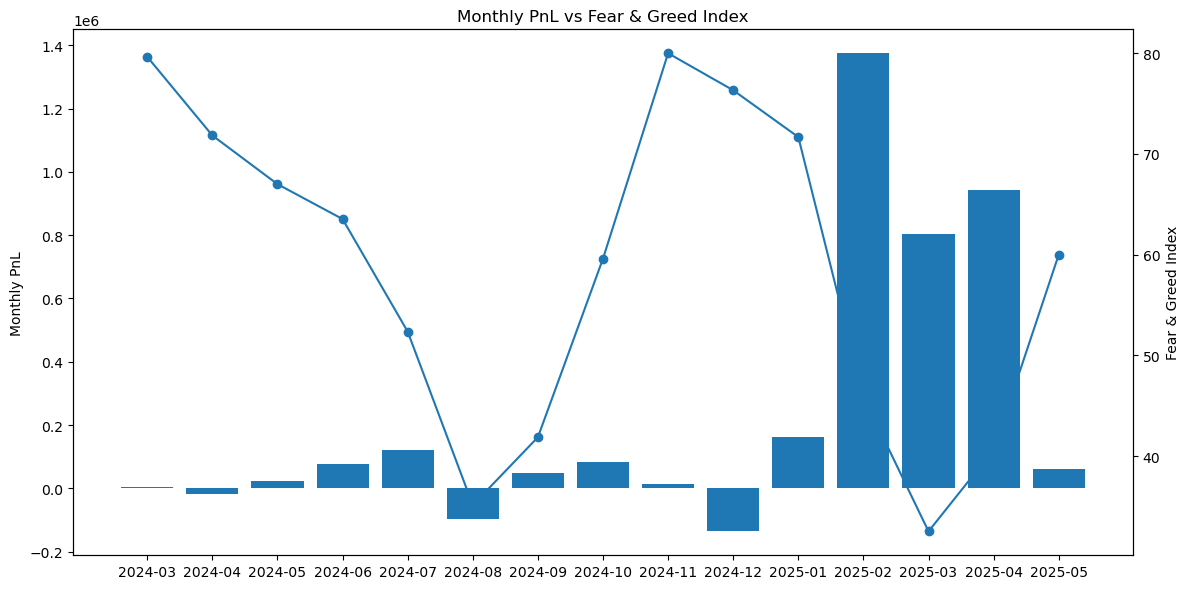

In [34]:
import matplotlib.pyplot as plt

monthly_pnl = (
    df.groupby('month')['Closed PnL']
      .sum()
      .reset_index()
)

fg_monthly = (
    sentiment.groupby('month')['value']
             .mean()
             .reset_index()
)

merged = pd.merge(
    monthly_pnl,
    fg_monthly,
    on='month'
)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    merged['month'].astype(str),
    merged['Closed PnL']
)

ax1.set_ylabel('Monthly PnL')

ax2 = ax1.twinx()

ax2.plot(
    merged['month'].astype(str),
    merged['value'],
    marker='o'
)

ax2.set_ylabel('Fear & Greed Index')

plt.title('Monthly PnL vs Fear & Greed Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

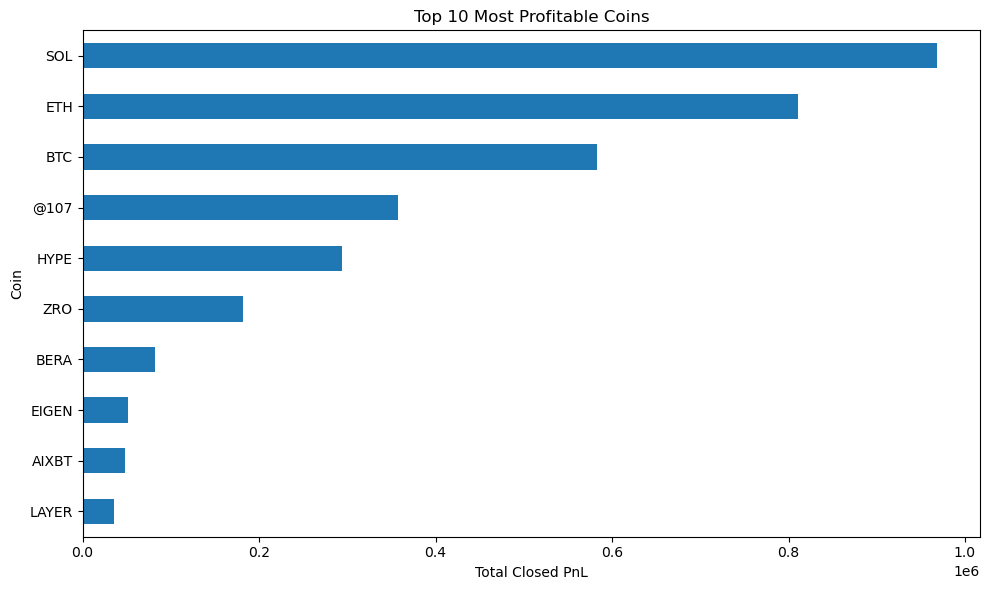

In [33]:
top_coins = (
    df.groupby('Coin')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_coins.sort_values().plot(kind='barh')

plt.title('Top 10 Most Profitable Coins')
plt.xlabel('Total Closed PnL')
plt.ylabel('Coin')
plt.tight_layout()
plt.show()

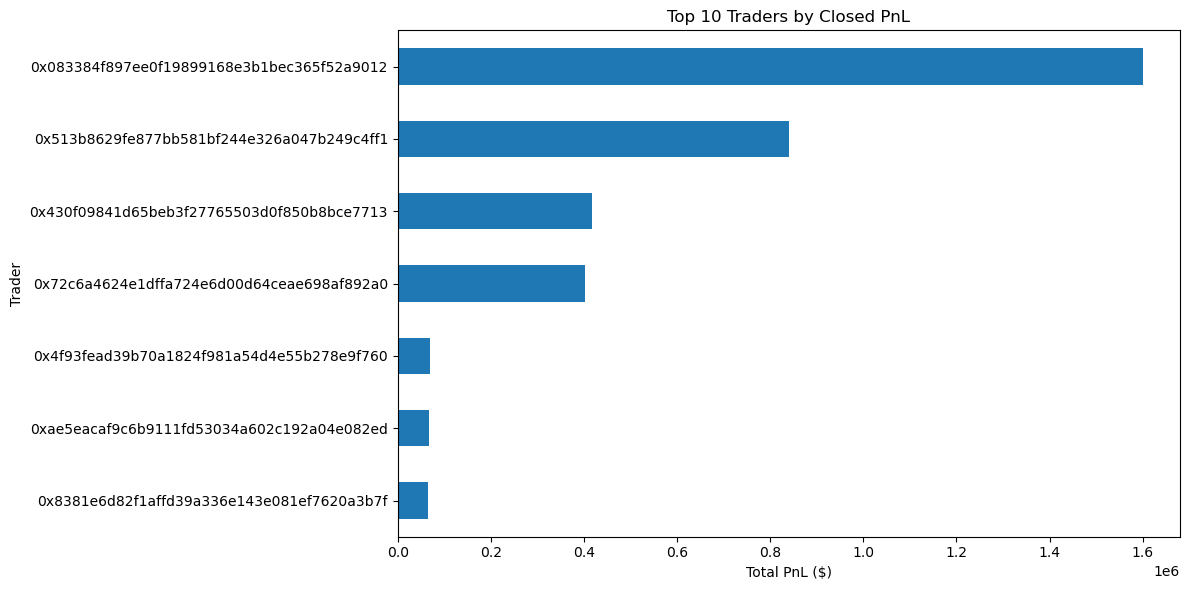

In [25]:
top_traders = (
    df.groupby('Account')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_traders.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Traders by Closed PnL')
plt.xlabel('Total PnL ($)')
plt.ylabel('Trader')
plt.tight_layout()
plt.show()

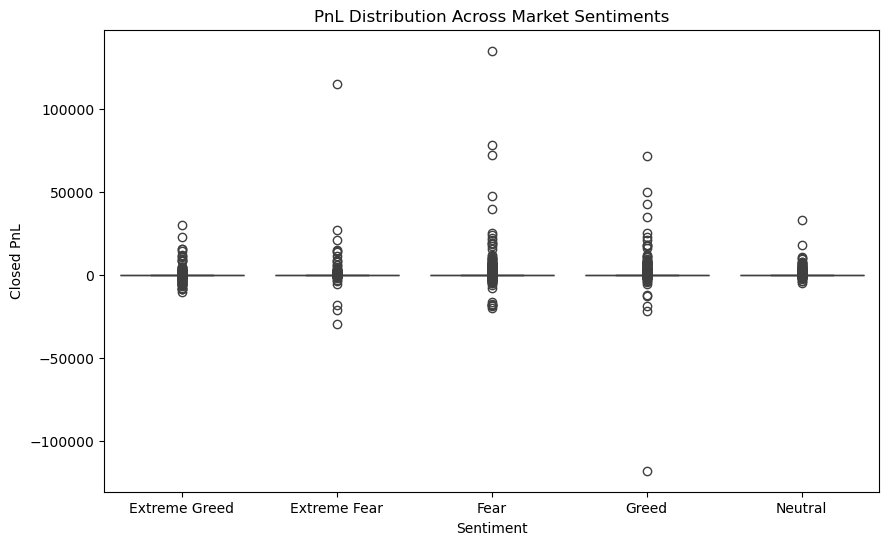

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution Across Market Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Closed PnL')

plt.show()